# Ingestion audit and first-pass visualisation

This notebook audits the consolidated colony observations dataset produced
by the ingestion pipeline, quantifies the two data-quality findings recorded
in the decisions directory, and generates the first-pass circumpolar map
combining the 26-colony observational record with the 71-colony 2025
circumpolar inventory.

In [1]:
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from eamp.common import config

DATE_TAG = date.today().isoformat()
TODAY = pd.Timestamp.today().normalize()
REALISTIC_START = pd.Timestamp("2018-01-01")
REALISTIC_END = TODAY

## 1. Load the most recent consolidated dataset

In [2]:
candidates = sorted(
    config.PENGUIN_PROCESSED.glob("eampA_colony_observations_long_*.parquet")
)
if not candidates:
    raise FileNotFoundError(
        f"No processed Parquet files found in {config.PENGUIN_PROCESSED}. "
        f"Run scripts/run_penguin_ingestion.py first."
    )
parquet_path = candidates[-1]
obs_all = pd.read_parquet(parquet_path)
print(f"Loaded {len(obs_all):,} observations from {parquet_path.name}")
print(f"Columns: {list(obs_all.columns)}")
obs_all.head()

Loaded 7,036 observations from eampA_colony_observations_long_2026-05-14.parquet
Columns: ['colony_id', 'colony_name', 'observation_date', 'latitude', 'longitude', 'surface_type', 'open_water_distance_km', 'comments', 'source_sheet']


,colony_id,colony_name,observation_date,latitude,longitude,surface_type,open_water_distance_km,comments,source_sheet
0,1,Umebosi,2018-03-14,NaN,NaN,NaN,NaN,"some fast ice left, but lots of open H2W; some...",1. Umebosi
1,1,Umebosi,2018-03-24,NaN,NaN,NaN,NaN,cloud,1. Umebosi
2,1,Umebosi,2018-03-31,NaN,NaN,NaN,NaN,cloud,1. Umebosi
3,1,Umebosi,2018-09-17,-68.046,43.077,fast_ice,50.0,pengs? Possible faint stain,1. Umebosi
4,1,Umebosi,2018-10-30,NaN,NaN,NaN,NaN,cloud,1. Umebosi


## 2. Apply temporal filter to exclude out-of-range dates

In [3]:
in_range_mask = (
    (obs_all["observation_date"] >= REALISTIC_START)
    & (obs_all["observation_date"] <= REALISTIC_END)
)
obs = obs_all.loc[in_range_mask].copy()
out_of_range = obs_all.loc[~in_range_mask].copy()

print(f"Realistic window: {REALISTIC_START.date()} to {REALISTIC_END.date()}")
print(f"  Observations within window:  {len(obs):,}")
print(f"  Observations outside window: {len(out_of_range)}")
print(f"  Filtered dataset date range: "
      f"{obs['observation_date'].min().date()} to "
      f"{obs['observation_date'].max().date()}")

Realistic window: 2018-01-01 to 2026-05-17
  Observations within window:  7,024
  Observations outside window: 12
  Filtered dataset date range: 2018-03-01 to 2025-12-31


## 3. Load the circumpolar 2025 inventory

In [4]:
inventory_path = config.PENGUIN_RAW / config.PENGUIN_INVENTORY_FILE
inventory = pd.read_excel(
    inventory_path, sheet_name=0, header=1, engine="openpyxl"
)
inventory = inventory.rename(
    columns={"Colony": "colony_name", "Date": "observation_date",
             "Lat": "latitude", "Long": "longitude"}
)
inventory["observation_date"] = pd.to_datetime(
    inventory["observation_date"], errors="coerce"
)
inventory = inventory.dropna(subset=["latitude", "longitude"]).reset_index(drop=True)
print(f"Loaded {len(inventory)} circumpolar colony locations from inventory")
inventory.head()

Loaded 71 circumpolar colony locations from inventory


,colony_name,observation_date,latitude,longitude
0,Cape Roget,2025-10-23,-71.98345,170.60720
1,Coulman Island,2025-10-23,-73.34676,169.64444
2,Cape Crozier,2025-10-17,-77.44769,169.26601
3,Franklin Island,2025-10-17,-76.17701,168.39342
4,Beaufort Island,2025-10-17,-76.93247,166.94391


## 4. Observations per colony (filtered dataset)

In [5]:
per_colony = (
    obs.groupby("colony_name")
    .agg(
        n_observations=("observation_date", "size"),
        first_observation=("observation_date", "min"),
        last_observation=("observation_date", "max"),
    )
    .sort_values("n_observations", ascending=False)
)
per_colony["record_duration_years"] = (
    per_colony["last_observation"] - per_colony["first_observation"]
).dt.days / 365.25
print(per_colony.to_string())

                        n_observations first_observation last_observation  record_duration_years
colony_name                                                                                     
Davies Bay                         367        2018-03-02       2025-12-30               7.830253
Pointe Geologie                    357        2018-09-19       2025-12-31               7.282683
Mertz Glacier                      331        2018-08-30       2025-12-28               7.329227
Sabrina Coast                      322        2018-03-28       2025-12-26               7.748118
Fold Island                        321        2018-04-02       2025-12-28               7.739904
Amundsen Bay                       317        2018-03-02       2025-12-26               7.819302
Umebosi                            315        2018-03-14       2025-12-26               7.786448
Yule Bay                           288        2018-03-13       2025-12-28               7.794661
Vanhoeffen                    

## 5. Out-of-range date audit

In [6]:
print(f"Rows with dates outside the expected window: {len(out_of_range)}")
print()
print(out_of_range[["colony_name", "observation_date", "source_sheet"]].to_string())

Rows with dates outside the expected window: 12

        colony_name observation_date       source_sheet
1281    Fold Island       2012-11-12     5. Fold Island
1282    Fold Island       2012-11-15     5. Fold Island
2791    Barrier Bay       2028-03-28    11. Barrier Bay
5181   Porpoise Bay       2026-11-30   21. Porpoise Bay
6048  Mertz Glacier       2014-11-03  24. Mertz Glacier
6496     Davies Bay       2010-10-10     26. Davies Bay
6964       Yule Bay              NaT       27. Yule Bay
6965       Yule Bay              NaT       27. Yule Bay
6966       Yule Bay              NaT       27. Yule Bay
6967       Yule Bay              NaT       27. Yule Bay
6968       Yule Bay              NaT       27. Yule Bay
6969       Yule Bay              NaT       27. Yule Bay


## 6. Surface type frequency

In [7]:
PRIORITY_CATEGORIES = {
    "fast_ice": "Fast ice (seasonal sea ice attached to shore)",
    "ice_floe": "Floating ice floe (free-floating sea ice)",
    "iceberg": "Iceberg (grounded or drifting freshwater ice)",
    "glacier_ice": "Glacier ice or ice tongue (floating glacier extension)",
    "ice_shelf": "Ice shelf (permanent floating ice extension of inland ice)",
}

surface_counts = obs["surface_type"].value_counts(dropna=False)
priority_mask = surface_counts.index.isin(PRIORITY_CATEGORIES.keys())

print("=== Priority categories ===")
for cat, description in PRIORITY_CATEGORIES.items():
    count = surface_counts.get(cat, 0)
    print(f"  {cat:>15}  {count:>5}  {description}")

print()
print("=== Other observed values (frequency >= 5) ===")
others = surface_counts[~priority_mask].sort_values(ascending=False)
for value, count in others.items():
    if count >= 5:
        print(f"  {str(value):>20}  {count:>5}")

print()
print(f"Total observations covered by priority categories: "
      f"{surface_counts[priority_mask].sum():,}")
print(f"Total observations in 'other' or null categories: "
      f"{surface_counts[~priority_mask].sum():,}")

=== Priority categories ===
         fast_ice   1854  Fast ice (seasonal sea ice attached to shore)
         ice_floe      0  Floating ice floe (free-floating sea ice)
          iceberg      5  Iceberg (grounded or drifting freshwater ice)
      glacier_ice      0  Glacier ice or ice tongue (floating glacier extension)
        ice_shelf      0  Ice shelf (permanent floating ice extension of inland ice)

=== Other observed values (frequency >= 5) ===
                   nan   4883
                  rock    102
             ice slope     67
                  land     37
              land ice     36
              land/ice     10
           glacier ice      7

Total observations covered by priority categories: 1,859
Total observations in 'other' or null categories: 5,165


## 7. Circumpolar visualisation

Rendered at 50m Natural Earth resolution for accurate colony placement
relative to the actual coast, following feedback from Barb that the
Umebosi colony at approximately 68.05S 43.08E should appear close to
the coastline rather than offshore.

In [8]:
obs_summary = (
    obs.groupby("colony_name")
    .agg(
        latitude=("latitude", "mean"),
        longitude=("longitude", "mean"),
        n_observations=("observation_date", "size"),
        first_observation=("observation_date", "min"),
        last_observation=("observation_date", "max"),
    )
    .reset_index()
)
obs_summary["record_duration_years"] = (
    obs_summary["last_observation"] - obs_summary["first_observation"]
).dt.days / 365.25

obs_names = set(obs_summary["colony_name"].str.lower().str.strip())
inventory["_match_key"] = inventory["colony_name"].str.lower().str.strip()
inventory_only = inventory[~inventory["_match_key"].isin(obs_names)].copy()

print(f"Observational colonies: {len(obs_summary)}")
print(f"Inventory-only colonies: {len(inventory_only)}")
print(f"Record duration range: "
      f"{obs_summary['record_duration_years'].min():.1f} to "
      f"{obs_summary['record_duration_years'].max():.1f} years")

Observational colonies: 26
Inventory-only colonies: 49
Record duration range: 6.8 to 7.8 years


Figure saved: /g/data/gv90/xl1657/phd/eamp/outputs/figures/penguin/eampA_circumpolar_overview_2026-05-17.png


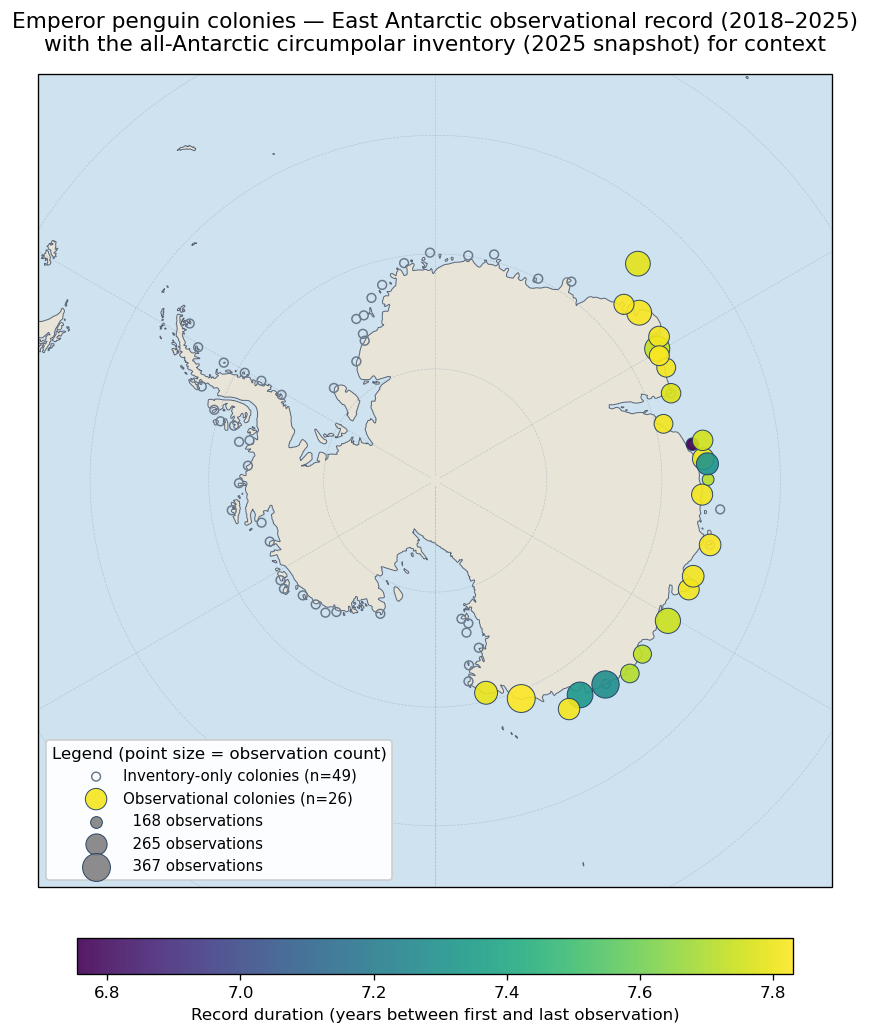

In [9]:
COASTLINE_RESOLUTION = "50m"

land_50m = cfeature.NaturalEarthFeature(
    category="physical", name="land", scale=COASTLINE_RESOLUTION,
    edgecolor="none", facecolor="#e8e4d8",
)
ocean_50m = cfeature.NaturalEarthFeature(
    category="physical", name="ocean", scale=COASTLINE_RESOLUTION,
    edgecolor="none", facecolor="#cfe2ef",
)
coastline_50m = cfeature.NaturalEarthFeature(
    category="physical", name="coastline", scale=COASTLINE_RESOLUTION,
    edgecolor="#5a6678", facecolor="none", linewidth=0.6,
)

fig = plt.figure(figsize=(11, 11), dpi=120)
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())

ax.add_feature(land_50m)
ax.add_feature(ocean_50m)
ax.add_feature(coastline_50m)
ax.gridlines(
    draw_labels=False, linewidth=0.4, color="#9aa6b8",
    alpha=0.5, linestyle="--",
)

ax.scatter(
    inventory_only["longitude"], inventory_only["latitude"],
    transform=ccrs.PlateCarree(),
    s=28, marker="o", facecolors="none",
    edgecolors="#6a7a8c", linewidths=0.9,
    label=f"Inventory-only colonies (n={len(inventory_only)})",
    zorder=4,
)

size_min, size_max = 50, 280
sizes = np.interp(
    obs_summary["n_observations"],
    (obs_summary["n_observations"].min(), obs_summary["n_observations"].max()),
    (size_min, size_max),
)

sc = ax.scatter(
    obs_summary["longitude"], obs_summary["latitude"],
    transform=ccrs.PlateCarree(),
    s=sizes, c=obs_summary["record_duration_years"],
    cmap="viridis",
    vmin=obs_summary["record_duration_years"].min(),
    vmax=obs_summary["record_duration_years"].max(),
    edgecolors="#1f3a5f", linewidths=0.6,
    alpha=0.9, zorder=5,
    label=f"Observational colonies (n={len(obs_summary)})",
)

cbar = plt.colorbar(sc, ax=ax, orientation="horizontal", pad=0.05, shrink=0.7)
cbar.set_label("Record duration (years between first and last observation)", fontsize=10)

size_legend_values = [
    int(obs_summary["n_observations"].min()),
    int(obs_summary["n_observations"].median()),
    int(obs_summary["n_observations"].max()),
]
size_legend_sizes = np.interp(
    size_legend_values,
    (obs_summary["n_observations"].min(), obs_summary["n_observations"].max()),
    (size_min, size_max),
)
for val, sz in zip(size_legend_values, size_legend_sizes):
    ax.scatter(
        [], [], s=sz, c="grey", edgecolors="#1f3a5f", linewidths=0.6,
        alpha=0.9, label=f"  {val:,} observations",
    )

ax.legend(
    loc="lower left", fontsize=9, frameon=True, framealpha=0.95,
    title="Legend (point size = observation count)",
    title_fontsize=10,
)

ax.set_title(
    "Emperor penguin colonies — East Antarctic observational record (2018–2025)\n"
    "with the all-Antarctic circumpolar inventory (2025 snapshot) for context",
    fontsize=13, pad=14,
)

config.PENGUIN_FIGURES.mkdir(parents=True, exist_ok=True)
figure_path = (
    config.PENGUIN_FIGURES / f"eampA_circumpolar_overview_{DATE_TAG}.png"
)
plt.savefig(figure_path, dpi=180, bbox_inches="tight", facecolor="white")
print(f"Figure saved: {figure_path}")
plt.show()

## 8. Summary export for the Wednesday email

In [10]:
summary = {
    "Total observations (raw)": f"{len(obs_all):,}",
    "Observations within realistic window": f"{len(obs):,}",
    "Out-of-range observations (excluded from visualisation)": len(out_of_range),
    "Colonies in observational record": obs["colony_name"].nunique(),
    "Colonies in 2025 circumpolar inventory": len(inventory),
    "Surface types observed (distinct, filtered)": obs["surface_type"].nunique(dropna=False),
    "Observations in 5 priority surface categories": int(
        surface_counts[priority_mask].sum()
    ),
    "Date range (filtered observational record)": (
        f"{obs['observation_date'].min().date()} to "
        f"{obs['observation_date'].max().date()}"
    ),
    "Record duration range (years)": (
        f"{obs_summary['record_duration_years'].min():.1f} to "
        f"{obs_summary['record_duration_years'].max():.1f}"
    ),
}
for label, value in summary.items():
    print(f"  {label:<55}  {value}")

  Total observations (raw)                                 7,036
  Observations within realistic window                     7,024
  Out-of-range observations (excluded from visualisation)  12
  Colonies in observational record                         26
  Colonies in 2025 circumpolar inventory                   71
  Surface types observed (distinct, filtered)              23
  Observations in 5 priority surface categories            1859
  Date range (filtered observational record)               2018-03-01 to 2025-12-31
  Record duration range (years)                            6.8 to 7.8
